**COM7021 – Data Visualisation Portfolio**

Student ID: 24138860

Bakery Sales Investigation – European Cities (2000–2005)

In [1]:
# 0. IMPORTS & DATA LOADING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os

warnings.filterwarnings("ignore")

In [3]:
# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_excel("Data Visualisation - COM7021 - [4566] Bakery- supporting document.xlsx")

In [4]:
# ── Clean & standardise ────────────────────────────────────────────────────────
# Standardise confectionery names (case/spelling inconsistencies)
df["Confectionary"] = (
    df["Confectionary"]
    .str.strip()
    .str.title()
    .replace({
        "Choclate Chunk": "Chocolate Chunk",   # fix typo
        "Caramel Nut": "Caramel Nut",           # keep consistent
    })
)

In [5]:
# Drop rows where ALL numeric columns are null
df.dropna(subset=["Units Sold", "Revenue(£)", "Cost(£)", "Profit(£)"], how="all", inplace=True)

In [6]:
# Fill remaining isolated nulls with column median (per city)
for col in ["Units Sold", "Revenue(£)", "Cost(£)", "Profit(£)"]:
    df[col] = df.groupby("City")[col].transform(lambda x: x.fillna(x.median()))

In [7]:
# Date features
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

In [8]:
# Profit margin %
df["Profit Margin (%)"] = (df["Profit(£)"] / df["Revenue(£)"]) * 100

In [9]:
print("Dataset shape after cleaning:", df.shape)
print("Cities:", df["City"].unique().tolist())
print("Confectionery:", sorted(df["Confectionary"].unique().tolist()))

Dataset shape after cleaning: (1001, 12)
Cities: ['London', 'Paris', 'Bonn', 'Seville', 'Napoli']
Confectionery: ['Biscuit', 'Biscuit Nut', 'Caramel', 'Caramel Nut', 'Chocolate Chunk', 'Plain']


In [10]:
# COLOUR PALETTES
CITY_COLORS = {
    "London":  "#1f77b4",
    "Paris":   "#ff7f0e",
    "Bonn":    "#2ca02c",
    "Seville": "#d62728",
    "Napoli":  "#9467bd",
}
CONF_PALETTE = sns.color_palette("tab10", n_colors=df["Confectionary"].nunique())
sns.set_theme(style="whitegrid", font_scale=1.1)

#  **TASK 1 – STATIC VISUALISATIONS (matplotlib / seaborn)**

In [11]:
os.makedirs("outputs", exist_ok=True)

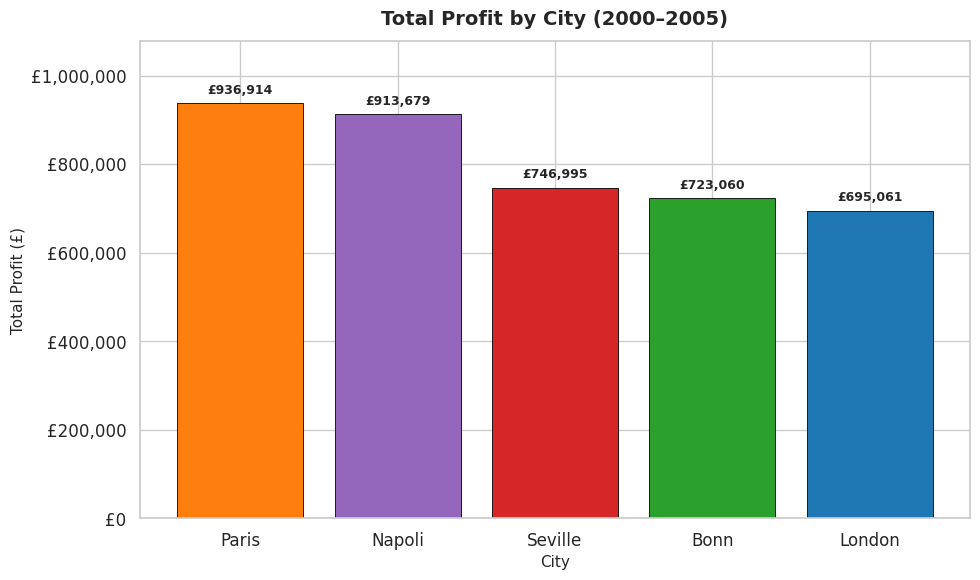

VIS 1 saved.


In [12]:
# ── VIS 1 : Total Profit by City (Bar Chart) ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
city_profit = df.groupby("City")["Profit(£)"].sum().sort_values(ascending=False)
bars = ax.bar(city_profit.index, city_profit.values,
              color=[CITY_COLORS[c] for c in city_profit.index], edgecolor="black", linewidth=0.6)
for bar, val in zip(bars, city_profit.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15000,
            f"£{val:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Total Profit by City (2000–2005)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("City", fontsize=11)
ax.set_ylabel("Total Profit (£)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.set_ylim(0, city_profit.max() * 1.15)
plt.tight_layout()
plt.savefig("outputs/vis1_total_profit_by_city.png", dpi=150)
plt.show()
print("VIS 1 saved.")

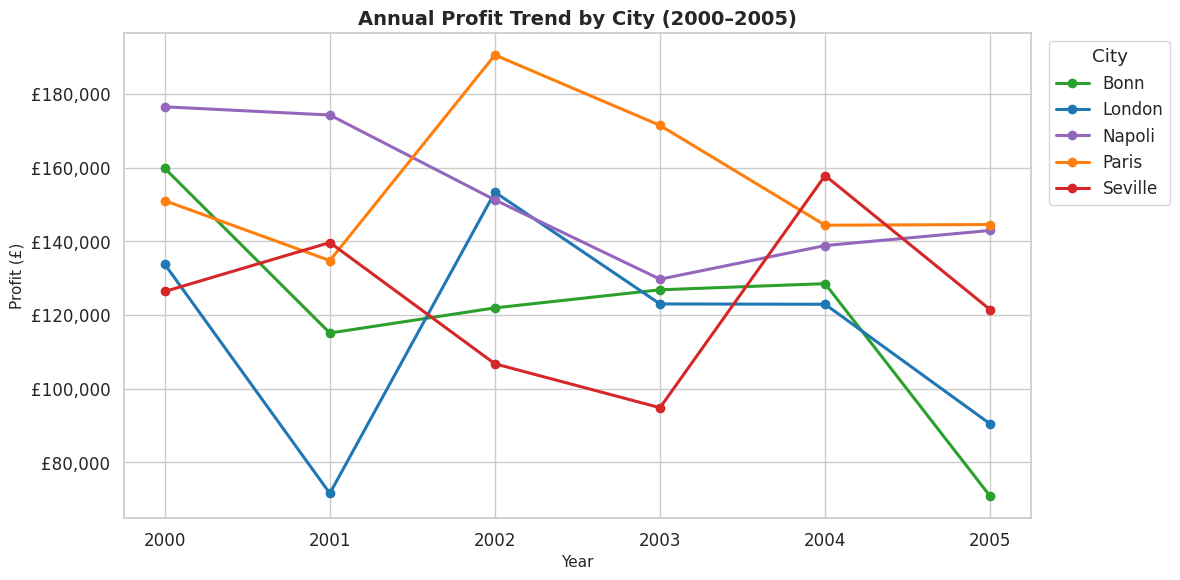

VIS 2 saved.


In [13]:
# ── VIS 2 : Annual Profit Trend by City (Line Chart) ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
annual = df.groupby(["Year", "City"])["Profit(£)"].sum().reset_index()
for city, grp in annual.groupby("City"):
    ax.plot(grp["Year"], grp["Profit(£)"], marker="o", linewidth=2.2,
            label=city, color=CITY_COLORS[city])
ax.set_title("Annual Profit Trend by City (2000–2005)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Profit (£)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.legend(title="City", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticks(annual["Year"].unique())
plt.tight_layout()
plt.savefig("outputs/vis2_annual_profit_trend.png", dpi=150)
plt.show()
print("VIS 2 saved.")

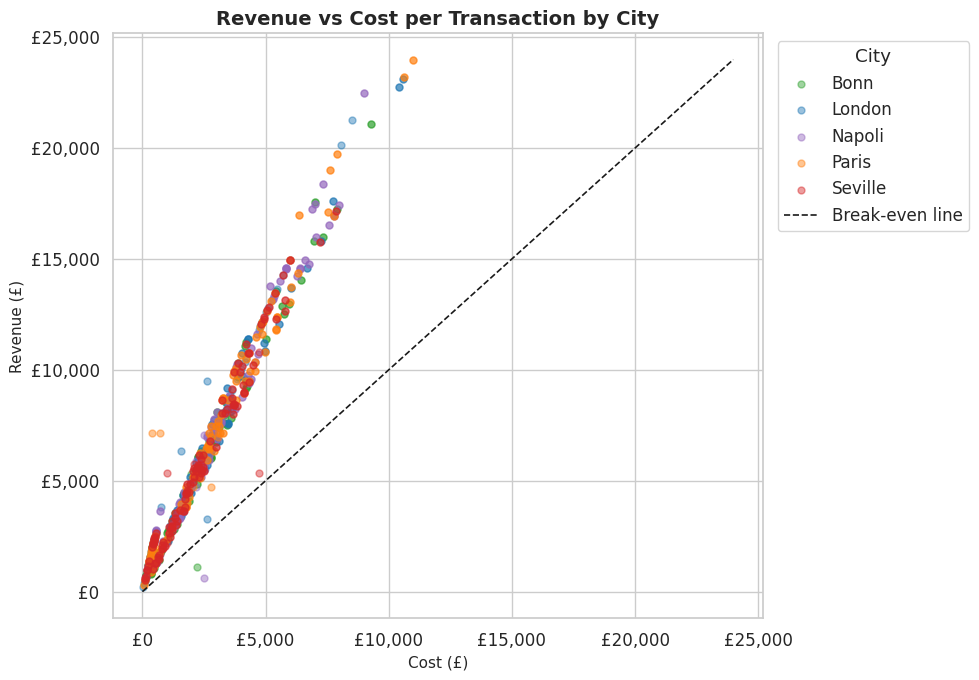

VIS 3 saved.


In [14]:
# ── VIS 3 : Revenue vs Cost Scatter (by City) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
for city, grp in df.groupby("City"):
    ax.scatter(grp["Cost(£)"], grp["Revenue(£)"], alpha=0.45, s=25,
               color=CITY_COLORS[city], label=city)
# Reference line: Revenue = Cost (break-even)
max_val = max(df["Cost(£)"].max(), df["Revenue(£)"].max())
ax.plot([0, max_val], [0, max_val], "k--", linewidth=1.2, label="Break-even line")
ax.set_title("Revenue vs Cost per Transaction by City", fontsize=14, fontweight="bold")
ax.set_xlabel("Cost (£)", fontsize=11)
ax.set_ylabel("Revenue (£)", fontsize=11)
ax.legend(title="City", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.tight_layout()
plt.savefig("outputs/vis3_revenue_vs_cost_scatter.png", dpi=150)
plt.show()
print("VIS 3 saved.")

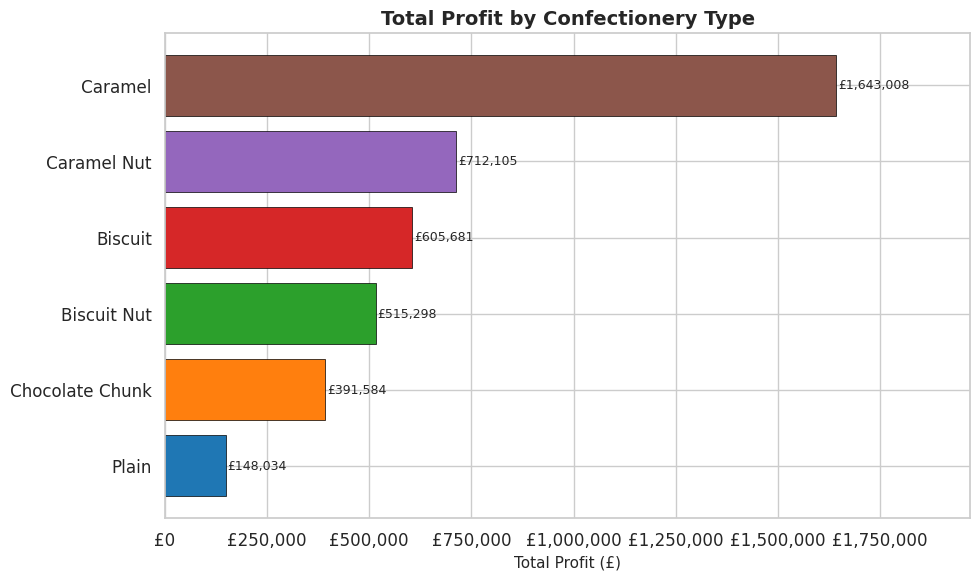

VIS 4 saved.


In [15]:
# ── VIS 4 : Profit by Confectionery Type (Horizontal Bar) ─────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
conf_profit = df.groupby("Confectionary")["Profit(£)"].sum().sort_values()
colors = CONF_PALETTE[:len(conf_profit)]
bars = ax.barh(conf_profit.index, conf_profit.values, color=colors, edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, conf_profit.values):
    ax.text(val + 5000, bar.get_y() + bar.get_height() / 2,
            f"£{val:,.0f}", va="center", fontsize=9)
ax.set_title("Total Profit by Confectionery Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Profit (£)", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.set_xlim(0, conf_profit.max() * 1.2)
plt.tight_layout()
plt.savefig("outputs/vis4_profit_by_confectionery.png", dpi=150)
plt.show()
print("VIS 4 saved.")

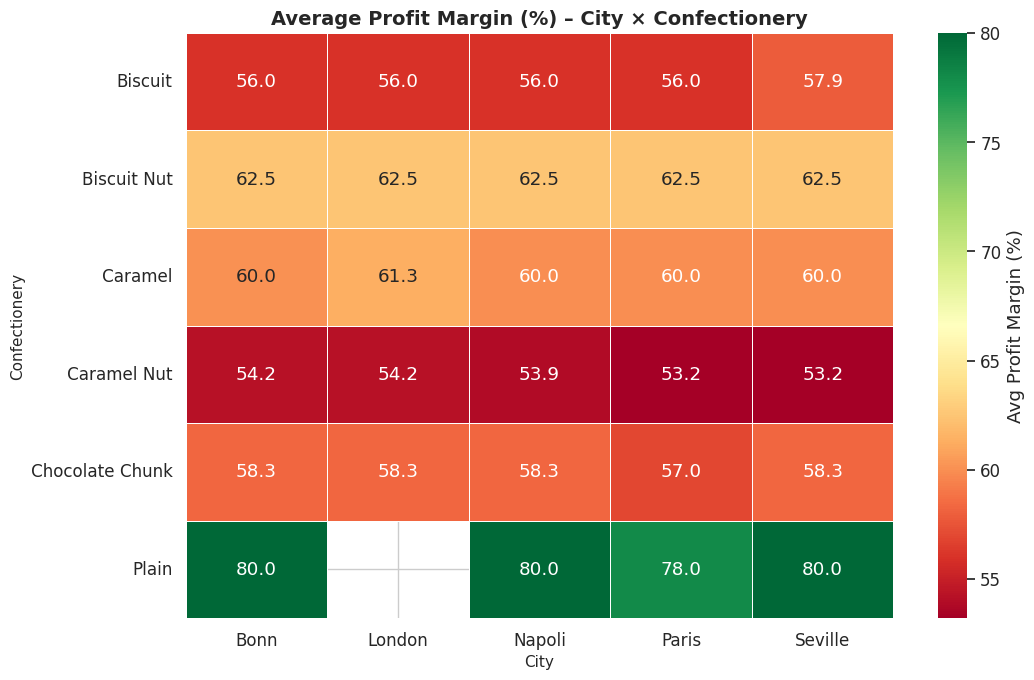

VIS 5 saved.


In [16]:
# ── VIS 5 : Heatmap – Average Profit Margin (City × Confectionery) ───────────
pivot_margin = df.pivot_table(
    values="Profit Margin (%)", index="Confectionary", columns="City", aggfunc="mean"
)
fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(pivot_margin, annot=True, fmt=".1f", cmap="RdYlGn",
            linewidths=0.5, linecolor="white", ax=ax,
            cbar_kws={"label": "Avg Profit Margin (%)"})
ax.set_title("Average Profit Margin (%) – City × Confectionery", fontsize=14, fontweight="bold")
ax.set_xlabel("City", fontsize=11)
ax.set_ylabel("Confectionery", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/vis5_heatmap_margin.png", dpi=150)
plt.show()
print("VIS 5 saved.")

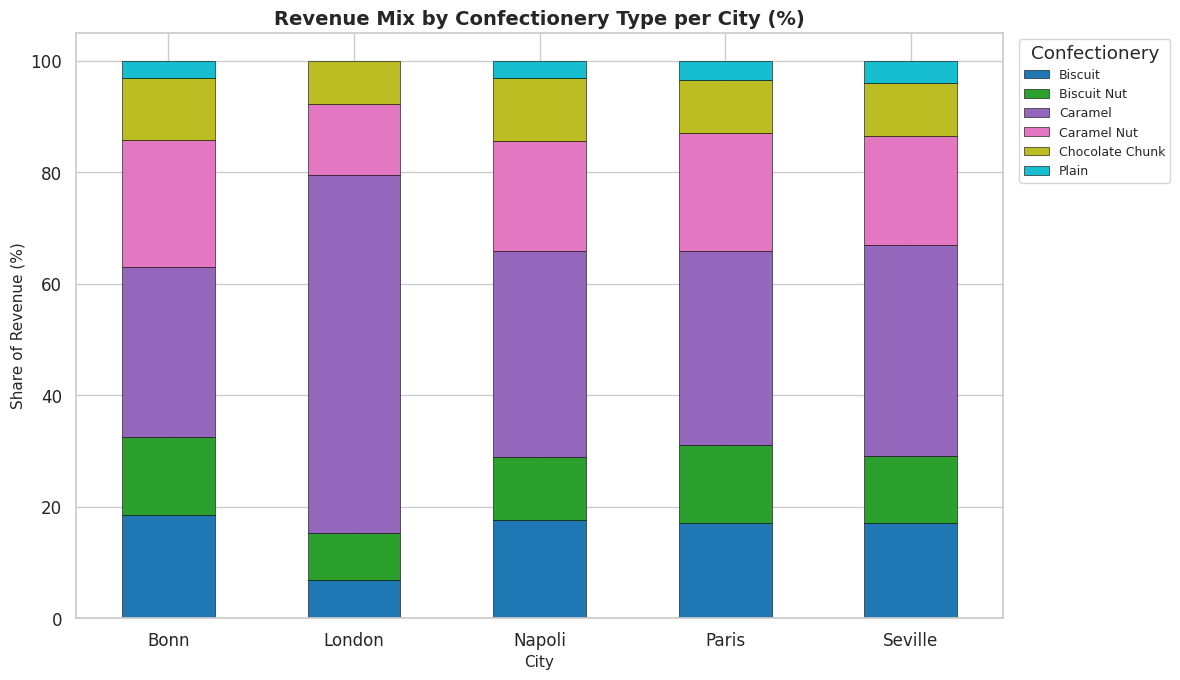

VIS 6 saved.


In [17]:
# ── VIS 6 : Stacked Bar – Confectionery Mix per City (Revenue %) ──────────────
pivot_rev = df.pivot_table(
    values="Revenue(£)", index="City", columns="Confectionary", aggfunc="sum", fill_value=0
)
pivot_pct = pivot_rev.div(pivot_rev.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(12, 7))
pivot_pct.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", edgecolor="black", linewidth=0.4)
ax.set_title("Revenue Mix by Confectionery Type per City (%)", fontsize=14, fontweight="bold")
ax.set_xlabel("City", fontsize=11)
ax.set_ylabel("Share of Revenue (%)", fontsize=11)
ax.set_ylim(0, 105)
ax.legend(title="Confectionery", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("outputs/vis6_stacked_revenue_mix.png", dpi=150)
plt.show()
print("VIS 6 saved.")

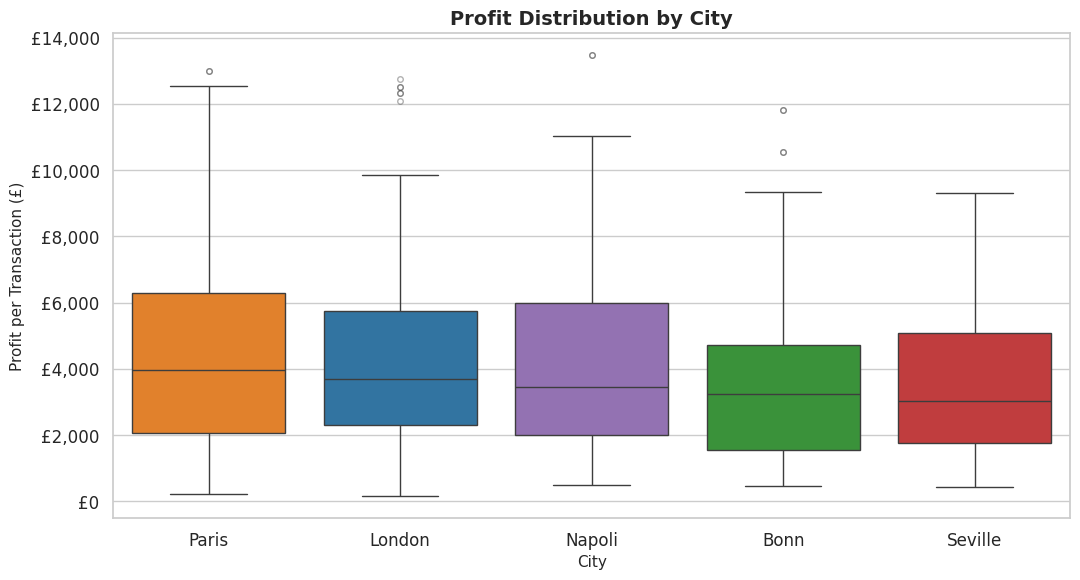

VIS 7 saved.


In [18]:
# ── VIS 7 : Box Plot – Profit Distribution by City ────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
order = df.groupby("City")["Profit(£)"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="City", y="Profit(£)", order=order,
            palette=CITY_COLORS, flierprops=dict(marker="o", alpha=0.4, markersize=4), ax=ax)
ax.set_title("Profit Distribution by City", fontsize=14, fontweight="bold")
ax.set_xlabel("City", fontsize=11)
ax.set_ylabel("Profit per Transaction (£)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.tight_layout()
plt.savefig("outputs/vis7_boxplot_profit_city.png", dpi=150)
plt.show()
print("VIS 7 saved.")

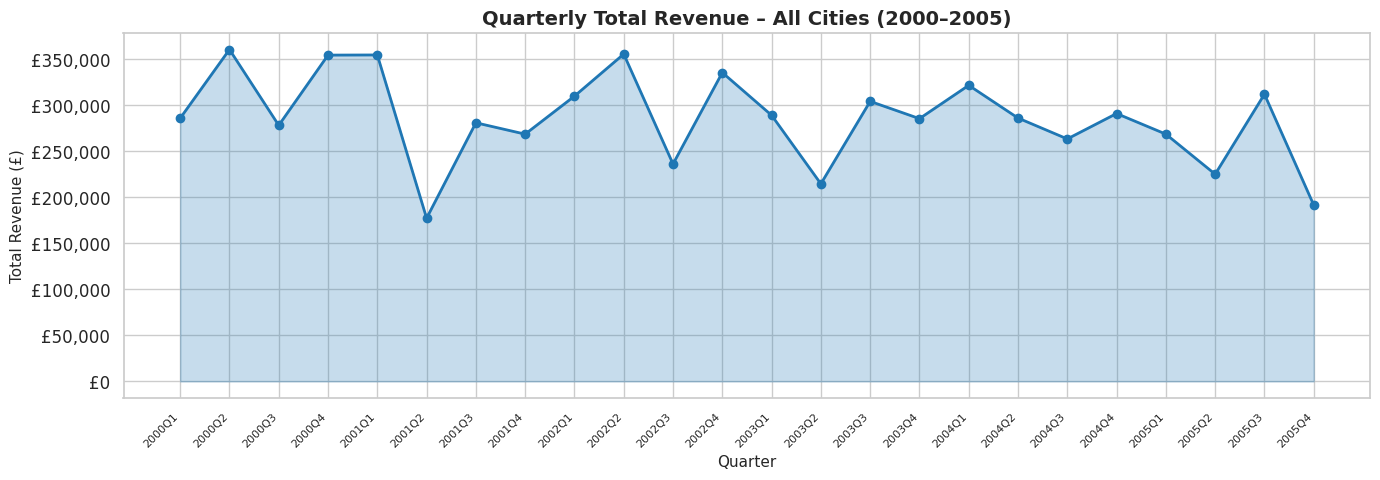

VIS 8 saved.


In [19]:
# ── VIS 8 : Quarterly Revenue Trend (all cities combined) ─────────────────────
quarterly = df.groupby("Quarter")["Revenue(£)"].sum().reset_index()
quarterly = quarterly.sort_values("Quarter")
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(range(len(quarterly)), quarterly["Revenue(£)"], alpha=0.25, color="#1f77b4")
ax.plot(range(len(quarterly)), quarterly["Revenue(£)"], marker="o", color="#1f77b4", linewidth=2)
ax.set_xticks(range(len(quarterly)))
ax.set_xticklabels(quarterly["Quarter"], rotation=45, ha="right", fontsize=8)
ax.set_title("Quarterly Total Revenue – All Cities (2000–2005)", fontsize=14, fontweight="bold")
ax.set_xlabel("Quarter", fontsize=11)
ax.set_ylabel("Total Revenue (£)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.tight_layout()
plt.savefig("outputs/vis8_quarterly_revenue_trend.png", dpi=150)
plt.show()
print("VIS 8 saved.")

# **TASK 1 – INTERACTIVE EUROPEAN DASHBOARD (Plotly)**

In [20]:
# City coordinates (approximate city centres)
CITY_COORDS = {
    "London":  {"lat": 51.509, "lon": -0.118},
    "Paris":   {"lat": 48.857, "lon":  2.352},
    "Bonn":    {"lat": 50.735, "lon":  7.099},
    "Seville": {"lat": 37.389, "lon": -5.984},
    "Napoli":  {"lat": 40.851, "lon": 14.268},
}

city_summary = df.groupby("City").agg(
    Total_Revenue=("Revenue(£)", "sum"),
    Total_Profit=("Profit(£)", "sum"),
    Total_Cost=("Cost(£)", "sum"),
    Avg_Margin=("Profit Margin (%)", "mean"),
    Transactions=("Profit(£)", "count"),
).reset_index()

city_summary["lat"] = city_summary["City"].map(lambda c: CITY_COORDS[c]["lat"])
city_summary["lon"] = city_summary["City"].map(lambda c: CITY_COORDS[c]["lon"])
city_summary["Avg_Margin_str"] = city_summary["Avg_Margin"].round(1).astype(str) + "%"

# Build multi-panel interactive dashboard
fig_dash = make_subplots(
    rows=3, cols=2,
    specs=[
        [{"type": "scattermapbox", "colspan": 2}, None],
        [{"type": "bar"}, {"type": "bar"}],
        [{"type": "scatter"}, {"type": "bar"}],
    ],
    subplot_titles=(
        "Interactive European Map – Total Profit by City",
        "Total Revenue by City",
        "Average Profit Margin (%) by City",
        "Annual Profit Trend by City",
        "Profit by Confectionery Type",
    ),
    vertical_spacing=0.10,
    horizontal_spacing=0.10,
)

# ── Panel 1 : Mapbox bubble map ────────────────────────────────────────────────
fig_dash.add_trace(
    go.Scattermapbox(
        lat=city_summary["lat"],
        lon=city_summary["lon"],
        mode="markers+text",
        marker=go.scattermapbox.Marker(
            size=city_summary["Total_Profit"] / city_summary["Total_Profit"].max() * 60 + 15,
            color=city_summary["Total_Profit"],
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(title="Total Profit (£)", x=1.0, len=0.35, y=0.85),
        ),
        text=city_summary["City"],
        textposition="top right",
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Total Profit: £%{customdata[0]:,.0f}<br>"
            "Total Revenue: £%{customdata[1]:,.0f}<br>"
            "Avg Margin: %{customdata[2]}<br>"
            "Transactions: %{customdata[3]:,}<extra></extra>"
        ),
        customdata=city_summary[["Total_Profit", "Total_Revenue", "Avg_Margin_str", "Transactions"]].values,
        name="Cities",
    ),
    row=1, col=1,
)
fig_dash.update_layout(
    mapbox=dict(
        style="carto-positron",
        center=dict(lat=46, lon=7),
        zoom=3.5,
    ),
)

# ── Panel 2 : Revenue by City ──────────────────────────────────────────────────
rev_sorted = city_summary.sort_values("Total_Revenue", ascending=False)
fig_dash.add_trace(
    go.Bar(
        x=rev_sorted["City"],
        y=rev_sorted["Total_Revenue"],
        marker_color=[CITY_COLORS[c] for c in rev_sorted["City"]],
        hovertemplate="<b>%{x}</b><br>Revenue: £%{y:,.0f}<extra></extra>",
        name="Revenue",
        showlegend=False,
    ),
    row=2, col=1,
)

# ── Panel 3 : Avg Profit Margin by City ───────────────────────────────────────
margin_sorted = city_summary.sort_values("Avg_Margin", ascending=False)
fig_dash.add_trace(
    go.Bar(
        x=margin_sorted["City"],
        y=margin_sorted["Avg_Margin"],
        marker_color=[CITY_COLORS[c] for c in margin_sorted["City"]],
        hovertemplate="<b>%{x}</b><br>Avg Margin: %{y:.1f}%<extra></extra>",
        name="Margin",
        showlegend=False,
    ),
    row=2, col=2,
)

# ── Panel 4 : Annual profit lines ─────────────────────────────────────────────
annual2 = df.groupby(["Year", "City"])["Profit(£)"].sum().reset_index()
added_to_legend = set()
for city, grp in annual2.groupby("City"):
    show = city not in added_to_legend
    added_to_legend.add(city)
    fig_dash.add_trace(
        go.Scatter(
            x=grp["Year"],
            y=grp["Profit(£)"],
            mode="lines+markers",
            name=city,
            line=dict(color=CITY_COLORS[city], width=2.5),
            marker=dict(size=6),
            showlegend=show,
            hovertemplate=f"<b>{city}</b><br>Year: %{{x}}<br>Profit: £%{{y:,.0f}}<extra></extra>",
        ),
        row=3, col=1,
    )

# ── Panel 5 : Profit by confectionery ─────────────────────────────────────────
conf_p = df.groupby("Confectionary")["Profit(£)"].sum().sort_values(ascending=False).reset_index()
fig_dash.add_trace(
    go.Bar(
        x=conf_p["Confectionary"],
        y=conf_p["Profit(£)"],
        marker_color=px.colors.qualitative.Set2[:len(conf_p)],
        hovertemplate="<b>%{x}</b><br>Profit: £%{y:,.0f}<extra></extra>",
        name="Confectionery Profit",
        showlegend=False,
    ),
    row=3, col=2,
)

# ── Global layout ──────────────────────────────────────────────────────────────
fig_dash.update_layout(
    title=dict(
        text="<b>European Bakery Sales Dashboard – COM7021 [4566]</b><br>"
             "<sup>Interactive profitability analysis across London, Paris, Bonn, Seville & Napoli (2000–2005)</sup>",
        x=0.5,
        font=dict(size=16),
    ),
    height=1350,
    template="plotly_white",
    legend=dict(title="City", orientation="v", x=1.02, y=0.35),
    font=dict(family="Arial", size=11),
    paper_bgcolor="white",
)

# Y-axis formatting for financial panels
for ref in ["yaxis2", "yaxis3", "yaxis5"]:
    fig_dash.update_layout(**{ref: dict(tickprefix="£", tickformat=",")})

fig_dash.update_yaxes(title_text="Total Revenue (£)", row=2, col=1)
fig_dash.update_yaxes(title_text="Avg Margin (%)", ticksuffix="%", row=2, col=2)
fig_dash.update_yaxes(title_text="Profit (£)", tickprefix="£", tickformat=",", row=3, col=1)
fig_dash.update_yaxes(title_text="Total Profit (£)", tickprefix="£", tickformat=",", row=3, col=2)
fig_dash.update_xaxes(title_text="Year", row=3, col=1)
fig_dash.update_xaxes(title_text="Confectionery", row=3, col=2)

fig_dash.write_html("outputs/interactive_dashboard.html")
fig_dash.show()
print("Interactive dashboard saved to outputs/interactive_dashboard.html")

Interactive dashboard saved to outputs/interactive_dashboard.html


# **SUPPLEMENTARY : Animated Profit Over Time (Plotly)**

In [21]:
annual_city = df.groupby(["Year", "City"]).agg(
    Profit=("Profit(£)", "sum"),
    Revenue=("Revenue(£)", "sum"),
    Units=("Units Sold", "sum"),
    Margin=("Profit Margin (%)", "mean"),
).reset_index()
annual_city["lat"] = annual_city["City"].map(lambda c: CITY_COORDS[c]["lat"])
annual_city["lon"] = annual_city["City"].map(lambda c: CITY_COORDS[c]["lon"])

fig_anim = px.scatter_geo(
    annual_city,
    lat="lat",
    lon="lon",
    size="Profit",
    color="City",
    animation_frame="Year",
    hover_name="City",
    hover_data={"Profit": ":,.0f", "Revenue": ":,.0f", "Margin": ":.1f", "lat": False, "lon": False},
    projection="natural earth",
    scope="europe",
    title="<b>Animated European Bakery Profit by City (2000–2005)</b>",
    color_discrete_map=CITY_COLORS,
    size_max=40,
)
fig_anim.update_layout(
    height=600,
    template="plotly_white",
    font=dict(family="Arial"),
    title_x=0.5,
)
fig_anim.write_html("outputs/animated_profit_map.html")
fig_anim.show()
print("Animated map saved to outputs/animated_profit_map.html")

Animated map saved to outputs/animated_profit_map.html


# **SUMMARY STATISTICS**

In [22]:
print("\n========== SUMMARY STATISTICS ==========")
print("\n--- Profit by City ---")
print(df.groupby("City")[["Revenue(£)", "Cost(£)", "Profit(£)", "Profit Margin (%)"]].agg(["sum", "mean"]).round(2))


========== SUMMARY STATISTICS ==========

--- Profit by City ---
        Revenue(£)             Cost(£)           Profit(£)           \
               sum     mean        sum     mean        sum     mean   
City                                                                  
Bonn     1231332.0  5863.49  510330.25  2430.14  723059.50  3443.14   
London   1191448.0  7400.30  493078.85  3062.60  695061.12  4317.15   
Napoli   1554023.0  7400.11  641464.00  3054.59  913678.70  4350.85   
Paris    1610573.0  7669.40  658414.20  3135.31  936914.20  4461.50   
Seville  1261605.0  6007.64  516527.50  2459.65  746995.00  3557.12   

        Profit Margin (%)         
                      sum   mean  
City                              
Bonn             12836.55  61.13  
London            9676.60  60.10  
Napoli           12799.46  60.95  
Paris            12783.93  60.88  
Seville          12920.88  61.53  


In [23]:
print("\n--- Profit by Confectionery ---")
print(df.groupby("Confectionary")[["Revenue(£)", "Profit(£)", "Profit Margin (%)"]].agg(["sum", "mean"]).round(2))


--- Profit by Confectionery ---
                Revenue(£)            Profit(£)          Profit Margin (%)  \
                       sum     mean         sum     mean               sum   
Confectionary                                                                
Biscuit          1076205.0  8679.07   605680.80  4884.52           7000.10   
Biscuit Nut       824476.0  6595.81   515297.50  4122.38           7812.50   
Caramel          2752695.0  7978.83  1643008.38  4762.34          20833.82   
Caramel Nut      1328621.0  8916.92   712104.75  4779.23           7997.30   
Chocolate Chunk   676701.0  4634.94   391583.50  2682.08           8472.43   
Plain             190283.0  1698.96   148033.60  1321.73           8901.28   

                        
                  mean  
Confectionary           
Biscuit          56.45  
Biscuit Nut      62.50  
Caramel          60.39  
Caramel Nut      53.67  
Chocolate Chunk  58.03  
Plain            79.48  


In [24]:
print("\n--- Annual Revenue ---")
print(df.groupby("Year")["Revenue(£)"].sum())


--- Annual Revenue ---
Year
2000    1278774.0
2001    1081229.0
2002    1236889.0
2003    1093164.0
2004    1161865.0
2005     997060.0
Name: Revenue(£), dtype: float64


In [25]:
print("\n--- Best Performing City × Confectionery Combos (Top 10 by Total Profit) ---")
best = (
    df.groupby(["City", "Confectionary"])["Profit(£)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
print(best.to_string(index=False))


--- Best Performing City × Confectionery Combos (Top 10 by Total Profit) ---
   City Confectionary  Profit(£)
 London       Caramel 451486.375
 Napoli       Caramel 343494.000
  Paris       Caramel 336582.000
Seville       Caramel 286518.000
   Bonn       Caramel 224928.000
  Paris   Caramel Nut 179290.000
 Napoli   Caramel Nut 166627.500
 Napoli       Biscuit 154112.000
  Paris       Biscuit 154060.400
   Bonn   Caramel Nut 152691.500


In [26]:
print("\nAll outputs saved to /outputs/")


All outputs saved to /outputs/
